<a href="https://colab.research.google.com/github/Trondster/CS4140//blob/main/documentation/Jupyter/Demo/drone_classification_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Run the pip install command once to install the dependencies - then restart the session and run all again. Fun with dependencies!**

In [1]:
!pip install "tensorflow==2.19.0" tf-keras tensorflow-model-optimization ai-edge-litert -q

Instructions: Upload `dataset.zip` from https://drive.google.com/file/d/1E1GRKtAh0No5De3GQojph6V3vIS9nVSM/view?usp=drive_link and `drone_model_ptq_int8.tflite` from `documentation\Jupyter\Demo\drone_classification_demo.ipynb` in the repo. Upload both files into the root folder of this notebook.

Then run. :\)


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf
import tf_keras as keras
from tf_keras import layers
import tensorflow_model_optimization as tfmot
from ai_edge_litert import interpreter as litert

print("TensorFlow:", tf.__version__)
print("Keras (legacy):", keras.__version__)

TensorFlow: 2.19.0
Keras (legacy): 2.19.0


# Extract zip

In [3]:
import os
import zipfile
import glob

# from google.colab import drive
# drive.mount('/content/drive')
# zip_file_path = 'drive/MyDrive/Embedded AI/dataset.zip'

#local upload
zip_file_path = 'dataset.zip'

# Global variables
DATASET_TO_USE = '2x2'

InputWidth = 80
InputHeight = 60


extract_root_path = '.'

# Ensure the top-level 'dataset' folder exists within the extract_root_path
os.makedirs(os.path.join(extract_root_path, 'dataset'), exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        all_members = zip_ref.namelist()

        # Define the prefixes for the subfolders you want to extract
        target_prefixes = [f'dataset/{DATASET_TO_USE}/', 'dataset/labels/', 'dataset/ignored/']

        destination_folders = [f'dataset/{DATASET_TO_USE}/clear/', f'dataset/{DATASET_TO_USE}/drone/', 'dataset/labels/', 'dataset/ignored/']
        for destination in destination_folders:
            deleted = 0
            destination_path = os.path.join(extract_root_path, destination, '*')
            print(f"Destination Path '{destination_path}'.")
            files = glob.glob(destination_path)
            for f in files:
                if os.path.isfile(f):
                    os.remove(f)
                    deleted = deleted + 1
            print(f"Deleted {deleted} files from '{destination_path}'.")

        members_to_extract = []
        for member in all_members:
            for prefix in target_prefixes:
                if member.startswith(prefix) or member == prefix.rstrip('/'): # Include the directory itself
                    members_to_extract.append(member)
                    break

        print(f"Extracting {len(members_to_extract)} selected items from '{zip_file_path}'...")

        # Extract only the selected members
        for member in members_to_extract:
            zip_ref.extract(member, path=extract_root_path)

    print(f"Successfully extracted selected subfolders to '{extract_root_path}'")

    # List the contents of the target 'dataset' folder to verify
    target_list_path = os.path.join(extract_root_path, 'dataset')
    print(f"Contents of '{target_list_path}':")
    for root, dirs, files in os.walk(target_list_path):
        level = root.replace(target_list_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Destination Path './dataset/2x2/clear/*'.
Deleted 10097 files from './dataset/2x2/clear/*'.
Destination Path './dataset/2x2/drone/*'.
Deleted 11014 files from './dataset/2x2/drone/*'.
Destination Path './dataset/labels/*'.
Deleted 10546 files from './dataset/labels/*'.
Destination Path './dataset/ignored/*'.
Deleted 379 files from './dataset/ignored/*'.
Extracting 32041 selected items from 'dataset.zip'...
Successfully extracted selected subfolders to '.'
Contents of './dataset':
dataset/
    ignored/
    2x2/
        clear/
        drone/
    labels/


In [4]:
import glob

# Define the paths to your image folders
drone_path = f'dataset/{DATASET_TO_USE}/drone'
clear_path = f'dataset/{DATASET_TO_USE}/clear'

# Get all image file paths from both folders
drone_images = glob.glob(os.path.join(drone_path, '*.png'))
clear_images = glob.glob(os.path.join(clear_path, '*.png'))

print(f"Found {len(drone_images)} drone images.")
print(f"Found {len(clear_images)} clear images.")

all_images = drone_images + clear_images
random.shuffle(all_images)

print(f"Total of {len(all_images)} images for training.")

Found 11014 drone images.
Found 10097 clear images.
Total of 21111 images for training.


The image filenames follow a pattern: `ID_type_frame.png` (e.g., `4407882_drone_current_frame.png`). For each unique `ID`, there should be a `_current_frame.png` and a `_diff_frame.png` image, and a corresponding `ID.txt` file in the `dataset/labels` folder. This `ID.txt` file contains the ground truth label (0 for clear, 1 for drone) and bounding box information.

We will now process all image paths to:
1.  Identify pairs of `current_frame` and `diff_frame` images based on their unique ID.
2.  Locate and read the corresponding `ID.txt` label file.
3.  Extract the label (first value in the `.txt` file) and bounding box data.
4.  Create a list `X` where each element is a tuple `(path_to_current_frame, path_to_diff_frame)`.
5.  Create a list `y` where each element is the integer label for the corresponding image pair.

In [5]:
import os
import glob
import random

# Combine all image paths from drone and clear categories
all_image_paths = drone_images + clear_images

# Dictionary to store image pairs and their label file path
image_pairs_data = {}

for img_path in all_image_paths:
    # Extract filename without extension
    basename = os.path.basename(img_path)
    filename_without_ext = os.path.splitext(basename)[0]

    # Extract unique ID and frame type
    # Example: '4407882_drone_current_frame' -> ID '4407882', frame_type 'current_frame'
    parts = filename_without_ext.split('_')
    image_id = parts[0]
    frame_type = '_'.join(parts[-2:]) # 'current_frame' or 'diff_frame'

    if image_id not in image_pairs_data:
        image_pairs_data[image_id] = {
            'current_frame': None,
            'diff_frame': None,
            'label_bbox': None # To store the (label, bbox) tuple
        }

    if 'current_frame' in frame_type:
        image_pairs_data[image_id]['current_frame'] = img_path
    elif 'diff_frame' in frame_type:
        image_pairs_data[image_id]['diff_frame'] = img_path

# Now, go through the image_pairs_data to find complete pairs and read labels
X_paired = [] # List of (current_frame_path, diff_frame_path)
y_labels_and_bboxes = [] # List of (integer label, bounding box data) tuples

label_dir = 'dataset/labels' # Directory where label .txt files are located

ignore_dir = 'dataset/ignored'

ignored = 0
num_clear_images = 0
num_drone_images = 0
for image_id, data in image_pairs_data.items():
    current_frame_path = data.get('current_frame')
    diff_frame_path = data.get('diff_frame')

    # Only process if both current and diff frames are found for this ID
    if current_frame_path and diff_frame_path:
        label_file_path = os.path.join(label_dir, f"{image_id}.txt")

        ignore_path = os.path.join(ignore_dir, f"{image_id}_ignored")

        if os.path.exists(ignore_path):
            # print(f"Ignoring ID {image_id} at {ignore_path}")
            ignored = ignored + 1
        elif os.path.exists(label_file_path):
            try:
                with open(label_file_path, 'r') as f:
                    # Assuming the format in .txt is: label_id bbox_x bbox_y bbox_width bbox_height
                    line = f.readline().strip()
                    parts = line.split()
                    if parts:
                        label = int(parts[0]) # The first value is the class label (0 or 1)
                        if label == 0:
                          num_clear_images = num_clear_images + 1
                        else:
                          num_drone_images = num_drone_images + 1

                        # If no bounding box is present (e.g., for clear images where bbox is not relevant or missing),
                        # default to [0.0, 0.0, 0.0, 0.0] for consistency in tuple structure.
                        bbox = [float(p) for p in parts[1:]] if len(parts) > 1 else [0.0, 0.0, 0.0, 0.0]

                        X_paired.append((current_frame_path, diff_frame_path))
                        y_labels_and_bboxes.append((label, bbox))
            except Exception as e:
                print(f"Error reading label file {label_file_path}: {e}")
        else:
            print(f"Warning: Label file not found for ID {image_id} at {label_file_path}")

# Shuffle the paired data and labels/bboxes together to maintain correspondence
combined_data = list(zip(X_paired, y_labels_and_bboxes))
random.shuffle(combined_data)

# Unpack combined_data. X will be a list of (current_frame_path, diff_frame_path) tuples.
# y_combined will be a list of (label, bbox) tuples.
X, y_combined = zip(*combined_data)
X = list(X)
y_combined = list(y_combined) # This is the list of (label, bbox) tuples

# Separate y_combined into classification labels and bounding box coordinates for model training
y_classification = [item[0] for item in y_combined]
y_bounding_box = [item[1] for item in y_combined]

print(f"Found {len(X)} complete image pairs with labels and bounding boxes.")
print(f"Clear: {num_clear_images}.")
print(f"Drone: {num_drone_images}.")
print(f"Ignored {ignored} image pairs.")
print(f"First 5 X (image pairs): {X[:5]}")
print(f"First 5 y_combined (labels and bboxes): {y_combined[:5]}")
print(f"First 5 y_classification (labels only): {y_classification[:5]}")
print(f"First 5 y_bounding_box (bboxes only): {y_bounding_box[:5]}")


Found 10167 complete image pairs with labels and bounding boxes.
Clear: 5075.
Drone: 5092.
Ignored 377 image pairs.
First 5 X (image pairs): [('dataset/2x2/drone/1167571_drone_current_frame.png', 'dataset/2x2/drone/1167571_drone_diff_frame.png'), ('dataset/2x2/drone/1067337_drone_current_frame.png', 'dataset/2x2/drone/1067337_drone_diff_frame.png'), ('dataset/2x2/clear/7027078455_clear_current_frame.png', 'dataset/2x2/clear/7027078455_clear_diff_frame.png'), ('dataset/2x2/drone/239288731351_drone_current_frame.png', 'dataset/2x2/drone/239288731351_drone_diff_frame.png'), ('dataset/2x2/clear/304303_clear_current_frame.png', 'dataset/2x2/clear/304303_clear_diff_frame.png')]
First 5 y_combined (labels and bboxes): [(1, [0.51875, 0.725333, 0.76875, 0.549333]), (1, [0.329688, 0.575667, 0.234375, 0.125]), (0, [0.0, 0.0, 0.0, 0.0]), (1, [0.921875, 0.684, 0.15625, 0.083333]), (0, [0.0, 0.0, 0.0, 0.0])]
First 5 y_classification (labels only): [1, 1, 0, 1, 0]
First 5 y_bounding_box (bboxes only)

### Data Augmentation: Horizontal Flipping

To increase the dataset size and improve model generalization, we will perform data augmentation by horizontally flipping each image pair (current_frame and diff_frame) and adjust the bounding box coordinates accordingly. For a bounding box defined as `[x_center, y_center, width, height]`, the `x_center` will be transformed to `1 - x_center` after a horizontal flip, while other coordinates remain unchanged.

In [6]:
import os
from PIL import Image

# DATASET_TO_USE, InputWidth, InputHeight are already defined globally

def augment_data_horizontal_flip(X_original, y_combined_original, output_dir_suffix="_flipped"):
    X_augmented = list(X_original) # Start with original data
    y_combined_augmented = list(y_combined_original) # Start with original data

    # Create a base directory for flipped images if it doesn't exist
    base_output_dir = 'dataset' + output_dir_suffix
    os.makedirs(base_output_dir, exist_ok=True)

    # Create subdirectories for the specific DATASET_TO_USE and labels
    for category in ['drone', 'clear']:
        os.makedirs(os.path.join(base_output_dir, DATASET_TO_USE, category), exist_ok=True)

    print(f"Augmenting dataset by horizontal flipping...")
    for i, (current_frame_path, diff_frame_path) in enumerate(X_original):
        label, bbox = y_combined_original[i]

        # Determine the relative path for saving flipped images
        # e.g., 'dataset/2x2/drone/ID_frame.png' -> '2x2/drone/ID_frame.png'
        relative_current_path = os.path.relpath(current_frame_path, 'dataset')
        relative_diff_path = os.path.relpath(diff_frame_path, 'dataset')

        flipped_current_frame_path = os.path.join(base_output_dir, relative_current_path)
        flipped_diff_frame_path = os.path.join(base_output_dir, relative_diff_path)

        # Load, flip, and save current_frame image
        img_current = Image.open(current_frame_path).transpose(Image.FLIP_LEFT_RIGHT)
        img_current.save(flipped_current_frame_path)

        # Load, flip, and save diff_frame image
        img_diff = Image.open(diff_frame_path).transpose(Image.FLIP_LEFT_RIGHT)
        img_diff.save(flipped_diff_frame_path)

        # Adjust bounding box coordinates for horizontal flip
        # Bbox format: [x_center, y_center, box_width, box_height]
        # For horizontal flip, only x_center changes: new_x_center = 1.0 - old_x_center
        flipped_bbox = list(bbox) # Create a mutable copy
        if label == 1 and len(bbox) == 4 and any(b > 0 for b in bbox): # Only flip if it's a drone and bbox is valid
            flipped_bbox[0] = 1.0 - bbox[0] # Adjust x_center

        # Add the flipped data to the augmented lists
        X_augmented.append((flipped_current_frame_path, flipped_diff_frame_path))
        y_combined_augmented.append((label, flipped_bbox))

    print(f"Original dataset size: {len(X_original)}")
    print(f"Augmented dataset size (original + flipped): {len(X_augmented)}")
    return X_augmented, y_combined_augmented

# Apply augmentation and update the data variables
X, y_combined = augment_data_horizontal_flip(X, y_combined)

# Re-separate y_combined into classification labels and bounding box coordinates for consistency
y_classification = [item[0] for item in y_combined]
y_bounding_box = [item[1] for item in y_combined]

print(f"Total data points after augmentation: {len(X)}")
print(f"First 5 X (image pairs) after augmentation: {X[:5]}")
print(f"First 5 y_combined (labels and bboxes) after augmentation: {y_combined[:5]}")

Augmenting dataset by horizontal flipping...
Original dataset size: 10167
Augmented dataset size (original + flipped): 20334
Total data points after augmentation: 20334
First 5 X (image pairs) after augmentation: [('dataset/2x2/drone/1167571_drone_current_frame.png', 'dataset/2x2/drone/1167571_drone_diff_frame.png'), ('dataset/2x2/drone/1067337_drone_current_frame.png', 'dataset/2x2/drone/1067337_drone_diff_frame.png'), ('dataset/2x2/clear/7027078455_clear_current_frame.png', 'dataset/2x2/clear/7027078455_clear_diff_frame.png'), ('dataset/2x2/drone/239288731351_drone_current_frame.png', 'dataset/2x2/drone/239288731351_drone_diff_frame.png'), ('dataset/2x2/clear/304303_clear_current_frame.png', 'dataset/2x2/clear/304303_clear_diff_frame.png')]
First 5 y_combined (labels and bboxes) after augmentation: [(1, [0.51875, 0.725333, 0.76875, 0.549333]), (1, [0.329688, 0.575667, 0.234375, 0.125]), (0, [0.0, 0.0, 0.0, 0.0]), (1, [0.921875, 0.684, 0.15625, 0.083333]), (0, [0.0, 0.0, 0.0, 0.0])]


In [7]:
import tensorflow as tf

# --- Configuration for image processing ---
# InputWidth and InputHeight are already defined globally
BATCH_SIZE = 32

# Function to preprocess a single image path
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    # Decode PNG as grayscale (channels=1)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [InputHeight, InputWidth])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img

# Function to load and preprocess a paired data point
def load_and_preprocess_data(current_frame_path, diff_frame_path, label, bbox):
    current_frame_img = preprocess_image(current_frame_path)
    diff_frame_img = preprocess_image(diff_frame_path)

    # Ensure labels and bboxes are correctly typed for TensorFlow
    label = tf.cast(label, tf.float32) # For binary classification
    bbox = tf.cast(bbox, tf.float32)   # For regression

    # Model inputs: tuple of (current_frame_img, diff_frame_img)
    # Model outputs: tuple of (classification_label, bounding_box_coordinates)
    return (current_frame_img, diff_frame_img), (label, bbox)

## Test TFLite Model Predictions on a Sample

In [12]:
from PIL import Image, ImageDraw

def visualize_tflite_prediction_with_bboxes(tflite_model_path, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth, header):
    current_frame_path, diff_frame_path = X_sample
    true_label = y_class_sample
    true_bbox_coords = y_bbox_sample

    interpreter = litert.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype_curr = input_details[0]["dtype"]
    input_dtype_diff = input_details[1]["dtype"]

    is_int8_curr = (input_dtype_curr == np.int8)
    is_int8_diff = (input_dtype_diff == np.int8)

    if is_int8_curr:
        scale_curr, zero_point_curr = input_details[0]["quantization"]
    if is_int8_diff:
        scale_diff, zero_point_diff = input_details[1]["quantization"]

    current_frame_img_processed = preprocess_image(current_frame_path)
    diff_frame_img_processed = preprocess_image(diff_frame_path)

    current_frame_sample = tf.expand_dims(current_frame_img_processed, axis=0).numpy()
    diff_frame_sample = tf.expand_dims(diff_frame_img_processed, axis=0).numpy()

    if is_int8_curr:
        current_frame_sample = (current_frame_sample / scale_curr + zero_point_curr).astype(np.int8)
    if is_int8_diff:
        diff_frame_sample = (diff_frame_sample / scale_diff + zero_point_diff).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], current_frame_sample)
    interpreter.set_tensor(input_details[1]["index"], diff_frame_sample)
    interpreter.invoke()

    # Find correct output indices by shape
    class_out_idx = None
    bbox_out_idx = None
    for i, detail in enumerate(output_details):
        if detail['shape'][-1] == 1:
            class_out_idx = i
        elif detail['shape'][-1] == 4:
            bbox_out_idx = i

    if class_out_idx is None or bbox_out_idx is None:
        raise ValueError("Could not identify classification and bbox output tensors")

    classification_output = interpreter.get_tensor(output_details[class_out_idx]["index"])
    bbox_output = interpreter.get_tensor(output_details[bbox_out_idx]["index"])

    if output_details[class_out_idx]["dtype"] == np.int8:
        output_scale_class, output_zero_point_class = output_details[class_out_idx]["quantization"]
        classification_output = (classification_output.astype(np.float32) - output_zero_point_class) * output_scale_class

    if output_details[bbox_out_idx]["dtype"] == np.int8:
        output_scale_bbox, output_zero_point_bbox = output_details[bbox_out_idx]["quantization"]
        bbox_output = (bbox_output.astype(np.float32) - output_zero_point_bbox) * output_scale_bbox

    predicted_label = 1 if classification_output[0][0] > 0.5 else 0
    predicted_bbox_coords = bbox_output[0]

    img_current = Image.open(current_frame_path).convert('RGB')
    img_diff = Image.open(diff_frame_path).convert('RGB')

    img_width, img_height = img_current.size
    draw_current = ImageDraw.Draw(img_current)
    draw_diff = ImageDraw.Draw(img_diff)

    def draw_bbox(draw_obj, bbox_coords, color, label_text):
        if bbox_coords is not None and len(bbox_coords) == 4 and any(b > 0 for b in bbox_coords):
            x_center, y_center, box_width, box_height = bbox_coords
            x_min = int((x_center - box_width / 2) * img_width)
            y_min = int((y_center - box_height / 2) * img_height)
            x_max = int((x_center + box_width / 2) * img_width)
            y_max = int((y_center + box_height / 2) * img_height)
            draw_obj.rectangle([(x_min, y_min), (x_max, y_max)], outline=color, width=2)
            try:
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color, font_size=12)
            except TypeError:
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color)

    if true_label == 1:
        draw_bbox(draw_current, true_bbox_coords, 'green', "GT")
        draw_bbox(draw_diff, true_bbox_coords, 'green', "GT")

    if predicted_label == 1:
        draw_bbox(draw_current, predicted_bbox_coords, 'red', "Pred")
        draw_bbox(draw_diff, predicted_bbox_coords, 'red', "Pred")

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_current)
    plt.title(f"Current Frame (TFLite) {header}\nTrue: {'Drone' if true_label == 1 else 'Clear'}, "
              f"Pred: {'Drone' if predicted_label == 1 else 'Clear'} ({classification_output[0][0]:.3f})\n{current_frame_path}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_diff)
    plt.title(f"Difference Frame (TFLite)\n{diff_frame_path}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# Select a random sample from the test set for visualization
# random_index = random.randint(0, len(X_test) - 1)
# X_sample_tflite = X_test[random_index]
# y_class_sample_tflite = y_classification_test[random_index]
# y_bbox_sample_tflite = y_bbox_test[random_index]

# models = {
#     "PTQ": "drone_model_ptq_int8.tflite",
#     "QAT": "drone_model_qat_int8.tflite"
# }

# visualize_tflite_prediction_with_bboxes(
#     models["PTQ"],
#     X_sample_tflite,
#     y_class_sample_tflite,
#     y_bbox_sample_tflite,
#     InputHeight,
#     InputWidth
# )

Testing the PTQ tflite model on a sample. Just run the cell below multiple times to test the inference.

This is the same inference as run on the deployed device, quantized to 8-bit.

The test is taken randomly from the entire training set used for training, validation, and test.

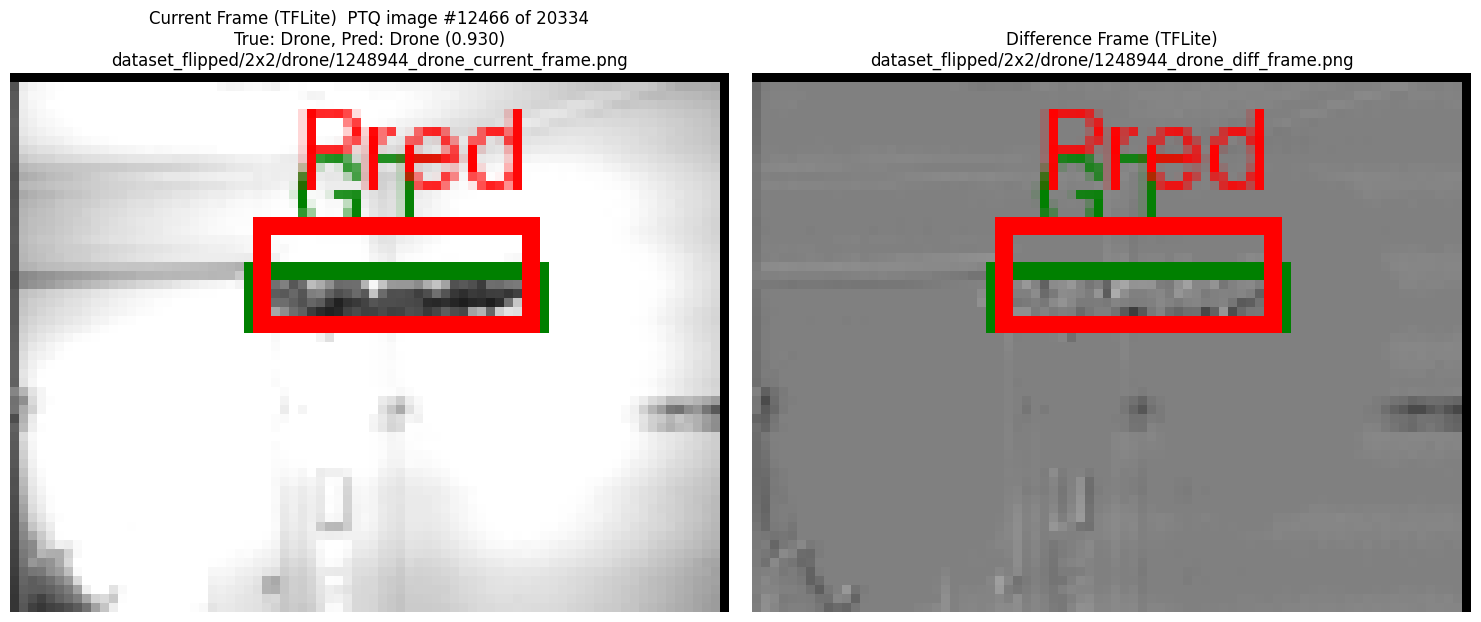

In [49]:
random_index = random.randint(0, len(X) - 1)
X_sample_tflite = X[random_index]
y_class_sample_tflite = y_classification[random_index]
y_bbox_sample_tflite = y_bounding_box[random_index]

visualize_tflite_prediction_with_bboxes(
    "drone_model_ptq_int8.tflite",
    X_sample_tflite,
    y_class_sample_tflite,
    y_bbox_sample_tflite,
    InputHeight,
    InputWidth,
    f" PTQ image #{random_index + 1} of {len(X)}"
)